In [24]:
import numpy as np
import pandas as pd

df = pd.read_csv('robot_dataset_final.csv')
df = df[df["d_footforce_dt"] > 0].copy()

df["log_footforce"] = np.log(df["footforce"])
df["log_dfootforce"] = np.log(df["d_footforce_dt"])
df["log_torque"] = np.log(df["total_torque"])
print(df.head())

       time  total_torque   footforce  d_footforce_dt environment  \
1   5647.18      0.005507  840.008333       14.045923    Corridor   
4   5647.48      0.000536  840.396930        6.438093    Corridor   
7   5647.78      0.000258  840.074997        4.359737    Corridor   
10  5648.08      0.000461  840.590864        0.603697    Corridor   
12  5648.29      0.000320  840.008333        6.575537    Corridor   

    log_footforce  log_dfootforce  log_torque  
1        6.733412        2.642332   -5.201815  
4        6.733874        1.862232   -7.531290  
7        6.733491        1.472412   -8.261499  
10       6.734105       -0.504683   -7.682455  
12       6.733412        1.883356   -8.046456  


In [33]:
import statsmodels.formula.api as smf

dirty_model = smf.ols(
    "log_torque ~ (log_footforce + log_dfootforce) * C(environment)",
    data=df
).fit()

print(dirty_model.summary())
influence = dirty_model.get_influence()
(cooks, p_values) = influence.cooks_distance

n=len(df)
threshold = 4/n
clean_data = df[cooks < threshold].copy()

clean_model = smf.ols("log_torque ~ (log_footforce + log_dfootforce) * C(environment)", data = clean_data).fit()

print(clean_model.summary())

y_clean = clean_data["log_torque"]
x_clean = pd.get_dummies(clean_data.drop(columns=["log_torque", "total_torque", "time", "footforce", "d_footforce_dt"]), drop_first=True)

                            OLS Regression Results                            
Dep. Variable:             log_torque   R-squared:                       0.424
Model:                            OLS   Adj. R-squared:                  0.423
Method:                 Least Squares   F-statistic:                     321.3
Date:                Wed, 17 Jun 2026   Prob (F-statistic):               0.00
Time:                        23:57:03   Log-Likelihood:                -7556.9
No. Observations:                4805   AIC:                         1.514e+04
Df Residuals:                    4793   BIC:                         1.522e+04
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                                               coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------

In [34]:
import sklearn.model_selection as ms
from sklearn import neighbors 
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

k_neighbors = list(range(1,21,2))   
n_grid = [{'n_neighbors': k_neighbors}]

X_train, X_test, y_train, y_test = ms.train_test_split(x_clean, y_clean, test_size=0.2, random_state=21)

model = neighbors.KNeighborsRegressor()

cv_knn = GridSearchCV(estimator=model, param_grid=n_grid, cv=ms.KFold(n_splits=10))
cv_knn.fit(X_train, y_train)

best_k = cv_knn.best_params_['n_neighbors']

optimized_knn = neighbors.KNeighborsRegressor(n_neighbors=best_k)
optimized_knn.fit(X_train, y_train)

knn_r2 = optimized_knn.score(X_test, y_test)
print("The R-squared of the KNN of the model is:", knn_r2)
y_pred = cv_knn.predict(X_test)
knn_mse = mean_squared_error(y_test, y_pred)
print("The MSE of the KNN of the model is:", knn_mse)

The R-squared of the KNN of the model is: 0.3831713732521864
The MSE of the KNN of the model is: 0.7111172416567517


In [35]:
from sklearn.ensemble import RandomForestRegressor

depth_val = np.arange(2,10)
leaf_val = np.arange(1,31, step=10)

grid_s = [{'max_depth': depth_val,'min_samples_leaf': leaf_val}]

cv_forest = GridSearchCV(RandomForestRegressor(), param_grid=grid_s, cv=ms.KFold(n_splits=5))
cv_forest.fit(X_train, y_train)
randomforest_r2 = cv_forest.score(X_test, y_test)
print("The R-squared of the random forest of the model is:", randomforest_r2)
y_pred = cv_forest.predict(X_test)
randomforest_mse = mean_squared_error(y_test, y_pred)
print("The MSE of the random forest of the model is:", randomforest_mse)

The R-squared of the random forest of the model is: 0.4304930684970878
The MSE of the random forest of the model is: 0.6565619374217656


[]

In [36]:
from sklearn.ensemble import AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor

depth_val = np.arange(2,10)
leaf_val = np.arange(1,31, step=10)

grid_s = [{'estimator__max_depth': depth_val,'estimator__min_samples_leaf': leaf_val}]
cv_forest = GridSearchCV(AdaBoostRegressor(estimator=DecisionTreeRegressor(), random_state=21), param_grid=grid_s, cv=ms.KFold(n_splits=5))
cv_forest.fit(X_train, y_train)
adaboost_r2 = cv_forest.score(X_test, y_test)
print("The R-squared of the Adaboost model is:", adaboost_r2)
y_pred = cv_forest.predict(X_test)
adaboost_mse = mean_squared_error(y_test, y_pred)
print("The MSE of the Adaboost of the model is:", adaboost_mse)

The R-squared of the Adaboost model is: 0.2470570514914716
The MSE of the Adaboost of the model is: 0.8680380407947469


(0.0, 1.0)

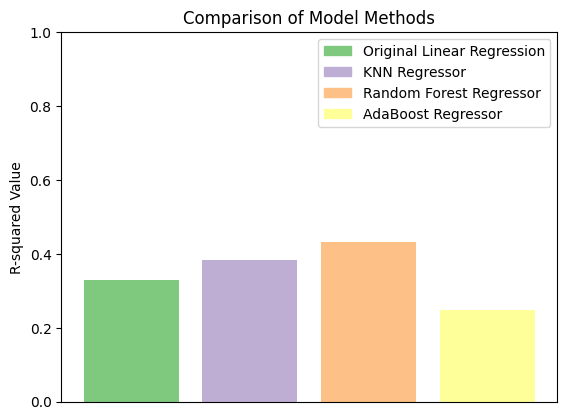

In [37]:
df = pd.DataFrame(
    {'Model': ['Original Linear Regression', 'KNN Regressor', 'Random Forest Regressor', 'AdaBoost Regressor'],
    'R2_Score': [0.33, knn_r2, randomforest_r2, adaboost_r2]
})

models = {'Original Linear Regression':'#7fc97f', 'KNN Regressor':'#beaed4', 'Random Forest Regressor':'#fdc086', 'AdaBoost Regressor':'#ffff99'}         
labels = list(models.keys())
handles = [plt.Rectangle((0,0),1,1, color=models[label]) for label in labels]
bars = plt.bar(df['Model'], df['R2_Score'], color = ['#7fc97f', '#beaed4', '#fdc086', '#ffff99'], label=False)
plt.legend(handles, labels)
plt.xticks([])
plt.ylabel('R-squared Value')
plt.title('Comparison of Model Methods')
plt.ylim(0, 1.0)